<a href="https://colab.research.google.com/github/TanujaMore27/Deep-Learning/blob/main/15_batchNormalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Batch Normalization :

* Batch Normalization (BN)is an algorithmic method which makes the training of deep neural networks(DNN) faster and more stable.
* It consists of normalizing activation vectors from hidden layers using the mean and variance of the current batch.This normalizing step is applied right before(or right after) the non-linear function.
* the main idea is all hidden layers outputs work as input to the next layer so we normalize this outputs by making mean=0 and S.D =1 before senting it as input to the next layer.


#### Why use batch Normalization :
* as we saw till now that normalizing inputs can make the training and convergence fast , so researchers think why should not it also applied to the outputs of neurons.
* to understand this concept first we need to understand concept called as :



**** Internal Covariate Shift :
* Covariate Shift :
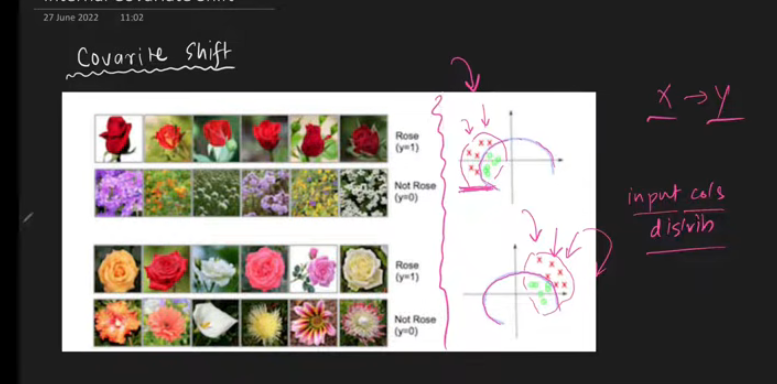


- when we made the curve of the distribution for input and output data , as shown in ss the decision boundary and the relation between x and y are same but the distribution of them is changed so our model doesn't work good on it so it is called as Covariant Shift.because even if our output distribution changes still have to retrain our model .
eg -- if we give images of red rose to the cnn model to identify roses and for testing we give different colour roses then we have to retrain our model due to covariate shift.

* We define Internal Covariate Shift as the change in the distribution of network activations due to change in network parameters during training.

* eg.Time Shift: A stock prediction model trained on data from 2020 fails to work in 2025 because market conditions have changed.

* Internal Covariate Shift: During training, as lower layers in a neural network update their weights, the input data feeding into deeper layers changes constantly, making training slow and unstable


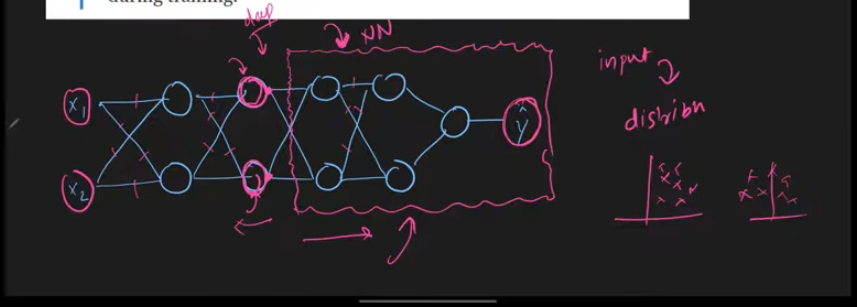


* if we only take the some last part of deep neural network then we can see that the input distribution to them is changing so there comes difficulty during training of these NN, called as Internal Covariate Shift.
* so by applying batch normalization there next layers got stable ground to do their work and improves our neural network.

*** if there is internal covariate shift and we are not using batch normalization then we need to take our learning rate low and have to do careful initialization of the weights and biases of the neurons as they will get unstable.

####  Batch Normalization - The How? :
* it is implemented using Mini-Batch Gradient
* we have to apply it one layer by layer so its optional to apply it for all layers at a same time.
* so when inputs are given we do weighted sum and then passed to an activation function and then its output given to next as input
* for this there are two ways to do batch normalization 1.we can normalize the weighted sum before passing the activation function and 2. we can normalize the output of this activation function , popular one is first.
* so to normalize we will take weighted sum subtract mean from it and divide by S.D, but from where this mean will come from? thats why we use mini batch normalization.




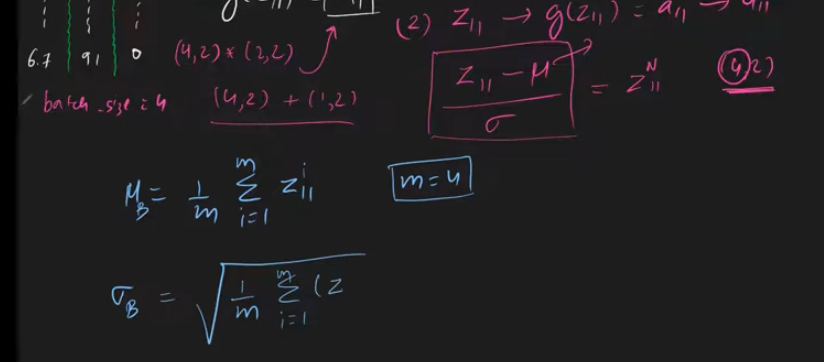

* we take mean of the new weighted sums(new means calculated by formula of adding some error) came from the neurons as per the number of batch rows we selected .and this is done for each neuron present in the layer.


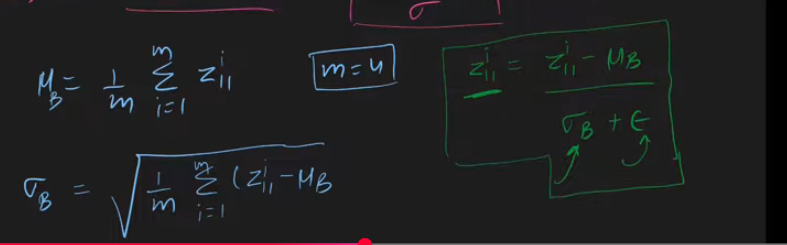

* after calculating the normalized weighted sum some other formula is also applied by multiplying it with gamma and adding B where both these are learnable parameters . In Keras the initial values are 1 for gamma and 0 for B and then they are given to the activation function. and this thing is done with all the neurons present in the layer , having there different values of these parameters.
* now after normalizing we are doing again some step of adding  and multiplying which is opposite to the normalization tanh at some point when there values becomes equal to what we divide and subtract during the normalization there will be no point of doing this , this is because sometimes the neural network doesn't need normalization so by gamma and B parameters we are giving it flexibility to adjust these parameters according to your need.


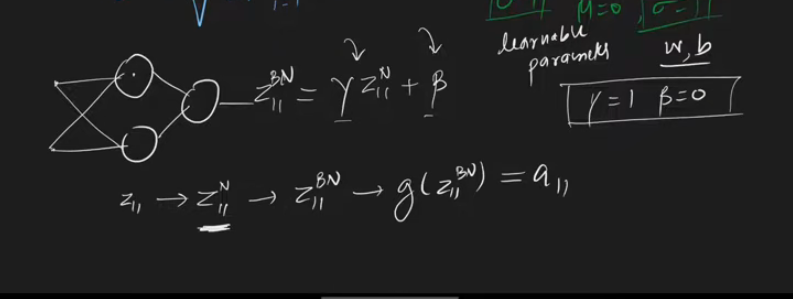

####  Batch Normalization During Test :
* during training we use this mini batch but how to get this mean and S.D during testing so for that we maintain Exponential Weighted Moving Average.
* so after normalizing during training we store the parameters such as mean,S.D,gamma and B for each time mini batch iterates and takes last updates values of mean and S.D.

*** gamma and B are learnable parameters and mean and S.D are non-learnable parameters.

*** Advantages :
- training is stable as during hyperparameter tuning we get wider range of values
- training becomes faster due to using higher learning rates
- can act as Regularizer , because the parameters values of mean and S.D are depend on batch and due to that changes comes in weighted sums normalization and their activation functions due to this some randomness is introduced allowing some noise in data which is good because it prevents from network to overfit . But this regularization is not that effective that we can relay on it we should use regularization techniques like dropouts upon requirements.
* reduce the impact of weight initialization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DL/dataset/concertriccir2.csv')

In [4]:
df.head()

,X,Y,class
0,0.70,-0.247,0.0
1,-3.95,2.740,1.0
2,0.15,-2.160,1.0
3,-1.67,-0.942,1.0
4,2.56,-1.850,1.0


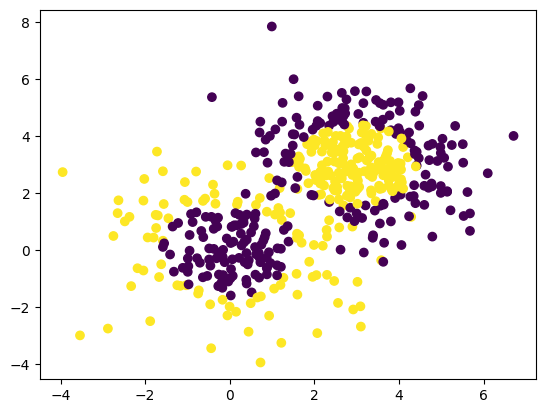

In [5]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [7]:
x = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [8]:
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import BatchNormalization

In [9]:
model = Sequential()

model.add(Dense(2,activation='relu',input_dim=2))
model.add(Dense(2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [11]:
history = model.fit(x,y,epochs=200,validation_split=0.2)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4650 - loss: 0.7490 - val_accuracy: 0.5700 - val_loss: 0.6724
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4450 - loss: 0.7382 - val_accuracy: 0.5700 - val_loss: 0.6663
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4200 - loss: 0.7294 - val_accuracy: 0.5700 - val_loss: 0.6624
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4150 - loss: 0.7231 - val_accuracy: 0.5700 - val_loss: 0.6604
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4100 - loss: 0.7177 - val_accuracy: 0.5600 - val_loss: 0.6597
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4200 - loss: 0.7135 - val_accuracy: 0.5400 - val_loss: 0.6596
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4225 - loss: 0.7104 - val_accuracy: 0.5200 - val_loss: 0.6600
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4275 - loss: 0.7078 - val_accuracy: 0.4900 - 

In [13]:
model = Sequential()

model.add(Dense(3,activation='relu',input_dim=2))
model.add(BatchNormalization())
model.add(Dense(2,activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3)              │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2)              │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [20]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [21]:
history1 = model.fit(x,y,epochs=200,validation_split=0.20)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5975 - loss: 0.6741 - val_accuracy: 0.4300 - val_loss: 0.6963
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6025 - loss: 0.6653 - val_accuracy: 0.4300 - val_loss: 0.7007
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6150 - loss: 0.6513 - val_accuracy: 0.4300 - val_loss: 0.7050
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6025 - loss: 0.6490 - val_accuracy: 0.4400 - val_loss: 0.7085
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6050 - loss: 0.6498 - val_accuracy: 0.4400 - val_loss: 0.7119
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6375 - loss: 0.6359 - val_accuracy: 0.4400 - val_loss: 0.7150
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6100 - loss: 0.6424 - val_accuracy: 0.4500 - val_loss: 0.7180
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6275 - loss: 0.6304 - val_accuracy: 0.4500 - 

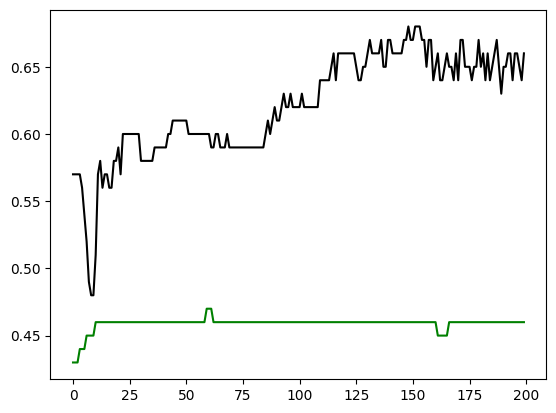

In [22]:
plt.plot(history.history['val_accuracy'],color='black')
plt.plot(history1.history['val_accuracy'],color='green')

In [23]:
history2 = model.fit(x,y,epochs=200,batch_size=64,validation_split=0.20)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7175 - loss: 0.4994 - val_accuracy: 0.4600 - val_loss: 0.7345
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7150 - loss: 0.5082 - val_accuracy: 0.4600 - val_loss: 0.7347
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7100 - loss: 0.5138 - val_accuracy: 0.4600 - val_loss: 0.7342
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7350 - loss: 0.4909 - val_accuracy: 0.4600 - val_loss: 0.7358
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7375 - loss: 0.4815 - val_accuracy: 0.4600 - val_loss: 0.7365
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7175 - loss: 0.4957 - val_accuracy: 0.4600 - val_loss: 0.7368
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7300 - loss: 0.4895 - val_accuracy: 0.4600 - val_loss: 0.7374
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7175 - loss: 0.4947 - val_accuracy: 0.4600 - val_loss:

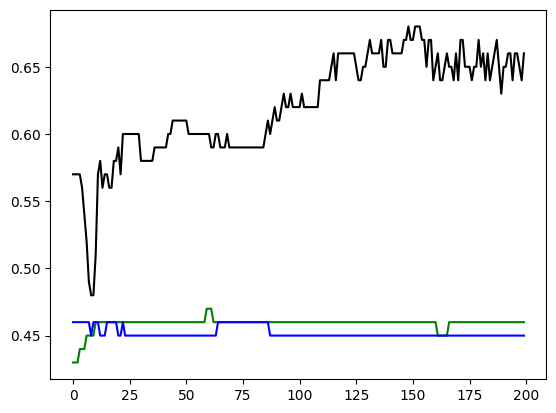

In [24]:
plt.plot(history.history['val_accuracy'],color='black')
plt.plot(history1.history['val_accuracy'],color='green')
plt.plot(history2.history['val_accuracy'],color='blue')